<a href="https://colab.research.google.com/github/Iannoh-png/Everything-Data-Official-Project/blob/main/Everything_Data_Official_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('fmcg_sales_3years_1M_rows.csv')

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
#1. Check for mising values
df.isnull().sum()

In [ ]:
# 2. Check for duplicates
df.duplicated().sum()

In [ ]:
# 3. Check date column type
df['date'].dtype

In [ ]:
# 4. Quick stats on key columns
df[['units_sold', 'gross_sales', 'net_sales', 'discount_pct']].describe()

In [ ]:
# Convert date column to proper datetime
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Verify it worked
df['date'].dtype

In [ ]:
# Check the date range of your dataset
print(df['date'].min())
print(df['date'].max())

In [ ]:
# 1. Sales summary by country
df.groupby('country')['gross_sales'].sum()\
  .sort_values(ascending=False)\
  .apply(lambda x: f"{x:,.0f}")

In [ ]:
# 2. Top 20 SKUs by revenue
df.groupby('sku_name')['gross_sales'].sum().sort_values(ascending=False).head(20)

In [ ]:
df[['units_sold', 'gross_sales', 'net_sales']].agg(['mean', 'median', 'std',])

In [ ]:
# Step 1 - Total revenue per SKU
sku_revenue = df.groupby('sku_name')['gross_sales']\
               .sum()\
               .sort_values(ascending=False)\
               .reset_index()
# Step 2 - Calculate cumulative percentage
sku_revenue['cumulative_pct'] = sku_revenue['gross_sales']\
                                .cumsum()/ sku_revenue['gross_sales']\
                                .sum() * 100
# Step 3 - Assign ABC labels
def abc_label(pct):
  if pct <= 80:
    return 'A'
  elif pct <= 95:
    return 'B'
  else:
    return 'C'

sku_revenue['ABC'] = sku_revenue['cumulative_pct'].apply(abc_label)

#Step 4 - Check the distribution
sku_revenue['ABC'].value_counts()

In [ ]:
# How many unique SKUs exist in the dataset
print(df['sku_name'].nunique())

# What does the revenue distribution look like?
print(sku_revenue['gross_sales'].describe())

# Check first 10 rows of your ABC table
print(sku_revenue.head(10))

In [ ]:
# Step 1 - Revenue per SKU per country
sku_country = df.groupby(['country', 'sku_name'])['gross_sales']\
                .sum()\
                .reset_index()

# Step 2 - Calculate cumulative % within each country
sku_country = sku_country.sort_values(['country', 'gross_sales'],
                                      ascending=[True, False])
sku_country['cumulative_pct'] = sku_country.groupby('country')['gross_sales']\
                                   .transform(lambda x: x.cumsum() / x.sum() * 100)

# Step 3 - Assign ABC per country

sku_country['ABC'] = sku_country['cumulative_pct'].apply(abc_label)

# Step 4 - Compare ABC distribution acros countries
sku_country.groupby(['country', 'ABC'])['sku_name']\
           .count()\
           .unstack()\
           .fillna(0)


In [ ]:
#XYZ Clasification
# Step 1 - Calculate monthly sales per SKU
monthly_sku = df.groupby(['sku_name',
                            df['date'].dt.to_period('M')])['units_sold']\
                            .sum()\
                            .reset_index()
# Step 2 - Calculate Coefficient of Variation (CV) per SKU
# Cv = std / mean - measures volatility
xyz = monthly_sku.groupby('sku_name')['units_sold']\
                 .agg(['mean', 'std'])\
                 .reset_index()

xyz['cv'] = xyz['std'] / xyz['mean']

# Step 3 - Assign XYZ labels
def xyz_label(cv):
  if cv <= 0.5:
    return 'X'
  elif cv <= 1.0:
    return 'Y'
  else:
    return 'Z'

xyz['XYZ'] = xyz['cv'].apply(xyz_label)

# Step 4 - Check distribution

print(xyz['XYZ'].value_counts())


In [ ]:
# Check if ABC or XYZ columns already exist in dataset
print(df.columns.tolist())

# Also check what's inside the ABC column we created
print(sku_country['ABC'].value_counts())

# Check cumulative_pct values - are they calculating correctly?
print(sku_country['cumulative_pct'].describe())

In [ ]:
abc_by_country = sku_country.groupby(['country', 'ABC'])['sku_name']\
                             .count()\
                             .unstack(fill_value=0)
print(abc_by_country)


In [ ]:
# Step 1 - Calculate monthly sales per SKU
monthly_sku = df.groupby(['sku_name', 'year', 'month'])['units_sold']\
                .sum()\
                .reset_index()



# Step 2 - Calculate CV per SKU
xyz['CV'] = xyz['std'] / xyz['mean']

# Step 3 - Assign XYZ labels
def xyz_label(cv):
  if cv < 0.5:
    return 'x'
  elif cv <= 1.0:
    return 'Y'
  else:
    return 'Z'

xyz['XYZ'] = xyz['CV'].apply(xyz_label)

# Step 4 - Check distribution
print(xyz['XYZ'].value_counts())

In [ ]:
# Check the actual CV values
print(xyz[['sku_name', 'CV']].sort_values('CV', ascending=False).head(10))

# Check the min and max CV
print("Max CV:", xyz['CV'].max())
print("Min CV:", xyz['CV'].min())

In [ ]:
# Step 1 - Correlation between key variables
correlation = df[['units_sold', 'list_price',
                  'discount_pct', 'promo_flag',
                  'gross_sales']].corr()
print(correlation)

# Step 2- Focus specifically on units_sold correlations
print(df[['units_sold', 'list_price',
          'discount_pct', 'promo_flag']].corr()['units_sold'])

In [ ]:
import matplotlib .pyplot as plt
import seaborn as sns
# Step 1- Monthly sales trend
monthly_sales = df.groupby(['year', 'month'])['gross_sales']\
                   .sum()\
                   .reset_index()
# Step 2 - Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='month',
             y = 'gross_sales', hue='year')
plt.title('Monthly Sales Seasonality by Year')
plt.xlabel('Month')
plt.ylabel('Gross Sales')
plt.xticks(range(1, 13), ['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()


In [ ]:
weekly_sales = df.groupby('weekday')['gross_sales']\
                 .mean()\
                 .reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_sales, x='weekday', y='gross_sales')
plt.title('Average Sales bby Day of Week')
plt.xlabel('Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Average Gross Sales')
plt.tight_layout()

plt.show()

In [ ]:
# See all categories available
print(df['category'].unique())

# Revenue per SKU with category
sku_profile = df.groupby(['sku_name', 'category'])['gross_sales']\
                .sum()\
                .sort_values(ascending=False)\
                .reset_index()
print(sku_profile.head(20))



In [ ]:
print(df[df['category'].isna()]['sku_name'].unique())
print(df['category'].isna().sum())

In [ ]:
print(df[df['category'].isna()])

In [ ]:
# Make sure selected_skus includes all 10
selected_skus = ['BrandA Toothpaste', 'BrandB Soap', 'BrandB Soda',
                 'BrandC Chips', 'BrandD Cheese', 'BrandD Detergent',
                 'BrandE Soda', 'BrandF Milk', 'BrandF Water', 'BrandF Nuts']

# Recreate forecast dataframe
sku_forecast_df = df[df['sku_name'].isin(selected_skus)]\
                  .groupby(['sku_name', 'year', 'month'])['units_sold']\
                  .sum()\
                  .reset_index()

# Verify all 10 SKUs are present
print(sku_forecast_df['sku_name'].unique().tolist())
print(sku_forecast_df.shape)

In [ ]:
# Check all unique SKus in forecast dataframe
print(sku_forecast_df['sku_name'].unique())

# Check how many months per SKU
print(sku_forecast_df.groupby('sku_name')['month'].count())

In [ ]:
print(sku_forecast_df['sku_name'].unique().tolist())


In [ ]:
print(selected_skus)

In [ ]:
selected_skus = ['BrandA Toothpaste', 'BrandB Soap', 'BrandB Soda',
                 'BrandC Chips', 'BrandD Cheese', 'BrandD Detergent',
                 'BrandE Soda', 'BrandF Milk', 'BrandF Water',
                 'BrandF Nuts']

print(len(selected_skus))

In [ ]:
for sku in selected_skus:
    # Filter for this SKU
    sku_data = sku_forecast_df[sku_forecast_df['sku_name'] == sku].copy()

    # ADD THIS LINE - tells us which SKU has 0 rows
    print(f"SKU: '{sku}' → Rows found: {len(sku_data)}")

In [ ]:
# See exactly what's in your forecast dataframe
print(sku_forecast_df['sku_name'].unique().tolist())

# See exactly what's in selected_skus
print(selected_skus)

In [ ]:
# Check if BrandF Nuts exists in original dataset
print(df[df['sku_name'] == 'BrandF Nuts']['units_sold'].sum())

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

results = []

for sku in selected_skus:
    # Filter for this SKU
    sku_data = sku_forecast_df[sku_forecast_df['sku_name'] == sku].copy()

    # Features and target
    X = sku_data[['year', 'month']]
    y = sku_data['units_sold']

    # Train model
    model = LinearRegression()
    model.fit(X, y)

    # R-squared score
    r2 = r2_score(y, model.predict(X))

    results.append({'sku': sku, 'r2_score': round(r2, 3)})

# View results
results_df = pd.DataFrame(results)
print(results_df.sort_values('r2_score', ascending=False))

In [ ]:
# We improve the model by adding more features
results2 = []

for sku in selected_skus:
  sku_data = df[df['sku_name'] == sku].copy()

  # Add more features this time
  X = sku_data[['year', 'month', 'discount_pct',
                'promo_flag', 'is_holiday', 'is_weekend',]]
  y = sku_data['units_sold']

  model = LinearRegression()
  model.fit(X, y)

  r2 = r2_score(y, model.predict(X))

  results2.append({'sku':sku, 'r2_score': round(r2, 3)})

results2_df = pd.DataFrame (results2)
print(results2_df.sort_values('r2_score', ascending=False))

In [ ]:
# Fix Use Monthly Data with more features
# Aggregate monthly with additional features
sku_forecast_df2 = df[df['sku_name'].isin(selected_skus)]\
                   .groupby(['sku_name', 'year', 'month'])\
                   .agg(
                       units_sold=('units_sold', 'sum'),
                       avg_discount=('discount_pct', 'mean'),
                       avg_promo=('promo_flag', 'mean'),
                       avg_holiday=('is_holiday', 'mean') # Add avg_holiday here
                   ).reset_index()
results3 = []

for sku in selected_skus:
  sku_data = sku_forecast_df2[sku_forecast_df2['sku_name'] == sku].copy()

  X = sku_data[['year', 'month', 'avg_discount',
                'avg_promo', 'avg_holiday']]
  y = sku_data['units_sold']

  model = LinearRegression()
  model.fit(X, y)

  r2 = r2_score(y, model.predict(X))

  results3.append({'sku': sku, 'r2_score': round(r2, 3)})

results3_df = pd.DataFrame(results3)
print(results3_df.sort_values('r2_score', ascending = False))

In [ ]:
sku_forecast_df3 = df[df['sku_name'].isin(selected_skus)]\
                   .groupby(['sku_name', 'year', 'month'])\
                   .agg(
                       units_sold=('units_sold', 'sum'),
                       avg_discount=('discount_pct', 'mean'),
                       avg_promo=('promo_flag', 'mean'),
                       avg_holiday=('is_holiday', 'mean'),
                       avg_temp=('temperature', 'mean'),
                       avg_rain=('rain_mm', 'mean')
                   ).reset_index()

results4 = []

for sku in selected_skus:
    sku_data = sku_forecast_df3[sku_forecast_df3['sku_name'] == sku].copy()

    X = sku_data[['year', 'month', 'avg_discount',
                  'avg_promo', 'avg_holiday',
                  'avg_temp', 'avg_rain']]
    y = sku_data['units_sold']

    model = LinearRegression()
    model.fit(X, y)

    r2 = r2_score(y, model.predict(X))

    results4.append({'sku': sku, 'r2_score': round(r2, 3)})

results4_df = pd.DataFrame(results4)
print(results4_df.sort_values('r2_score', ascending=False))

                 sku  r2_score
3       BrandC Chips     0.628
9        BrandF Nuts     0.615
5   BrandD Detergent     0.360
7        BrandF Milk     0.233
0  BrandA Toothpaste     0.184
6        BrandE Soda     0.120
1        BrandB Soap     0.106
4      BrandD Cheese     0.091
2        BrandB Soda     0.038
8       BrandF Water     0.034


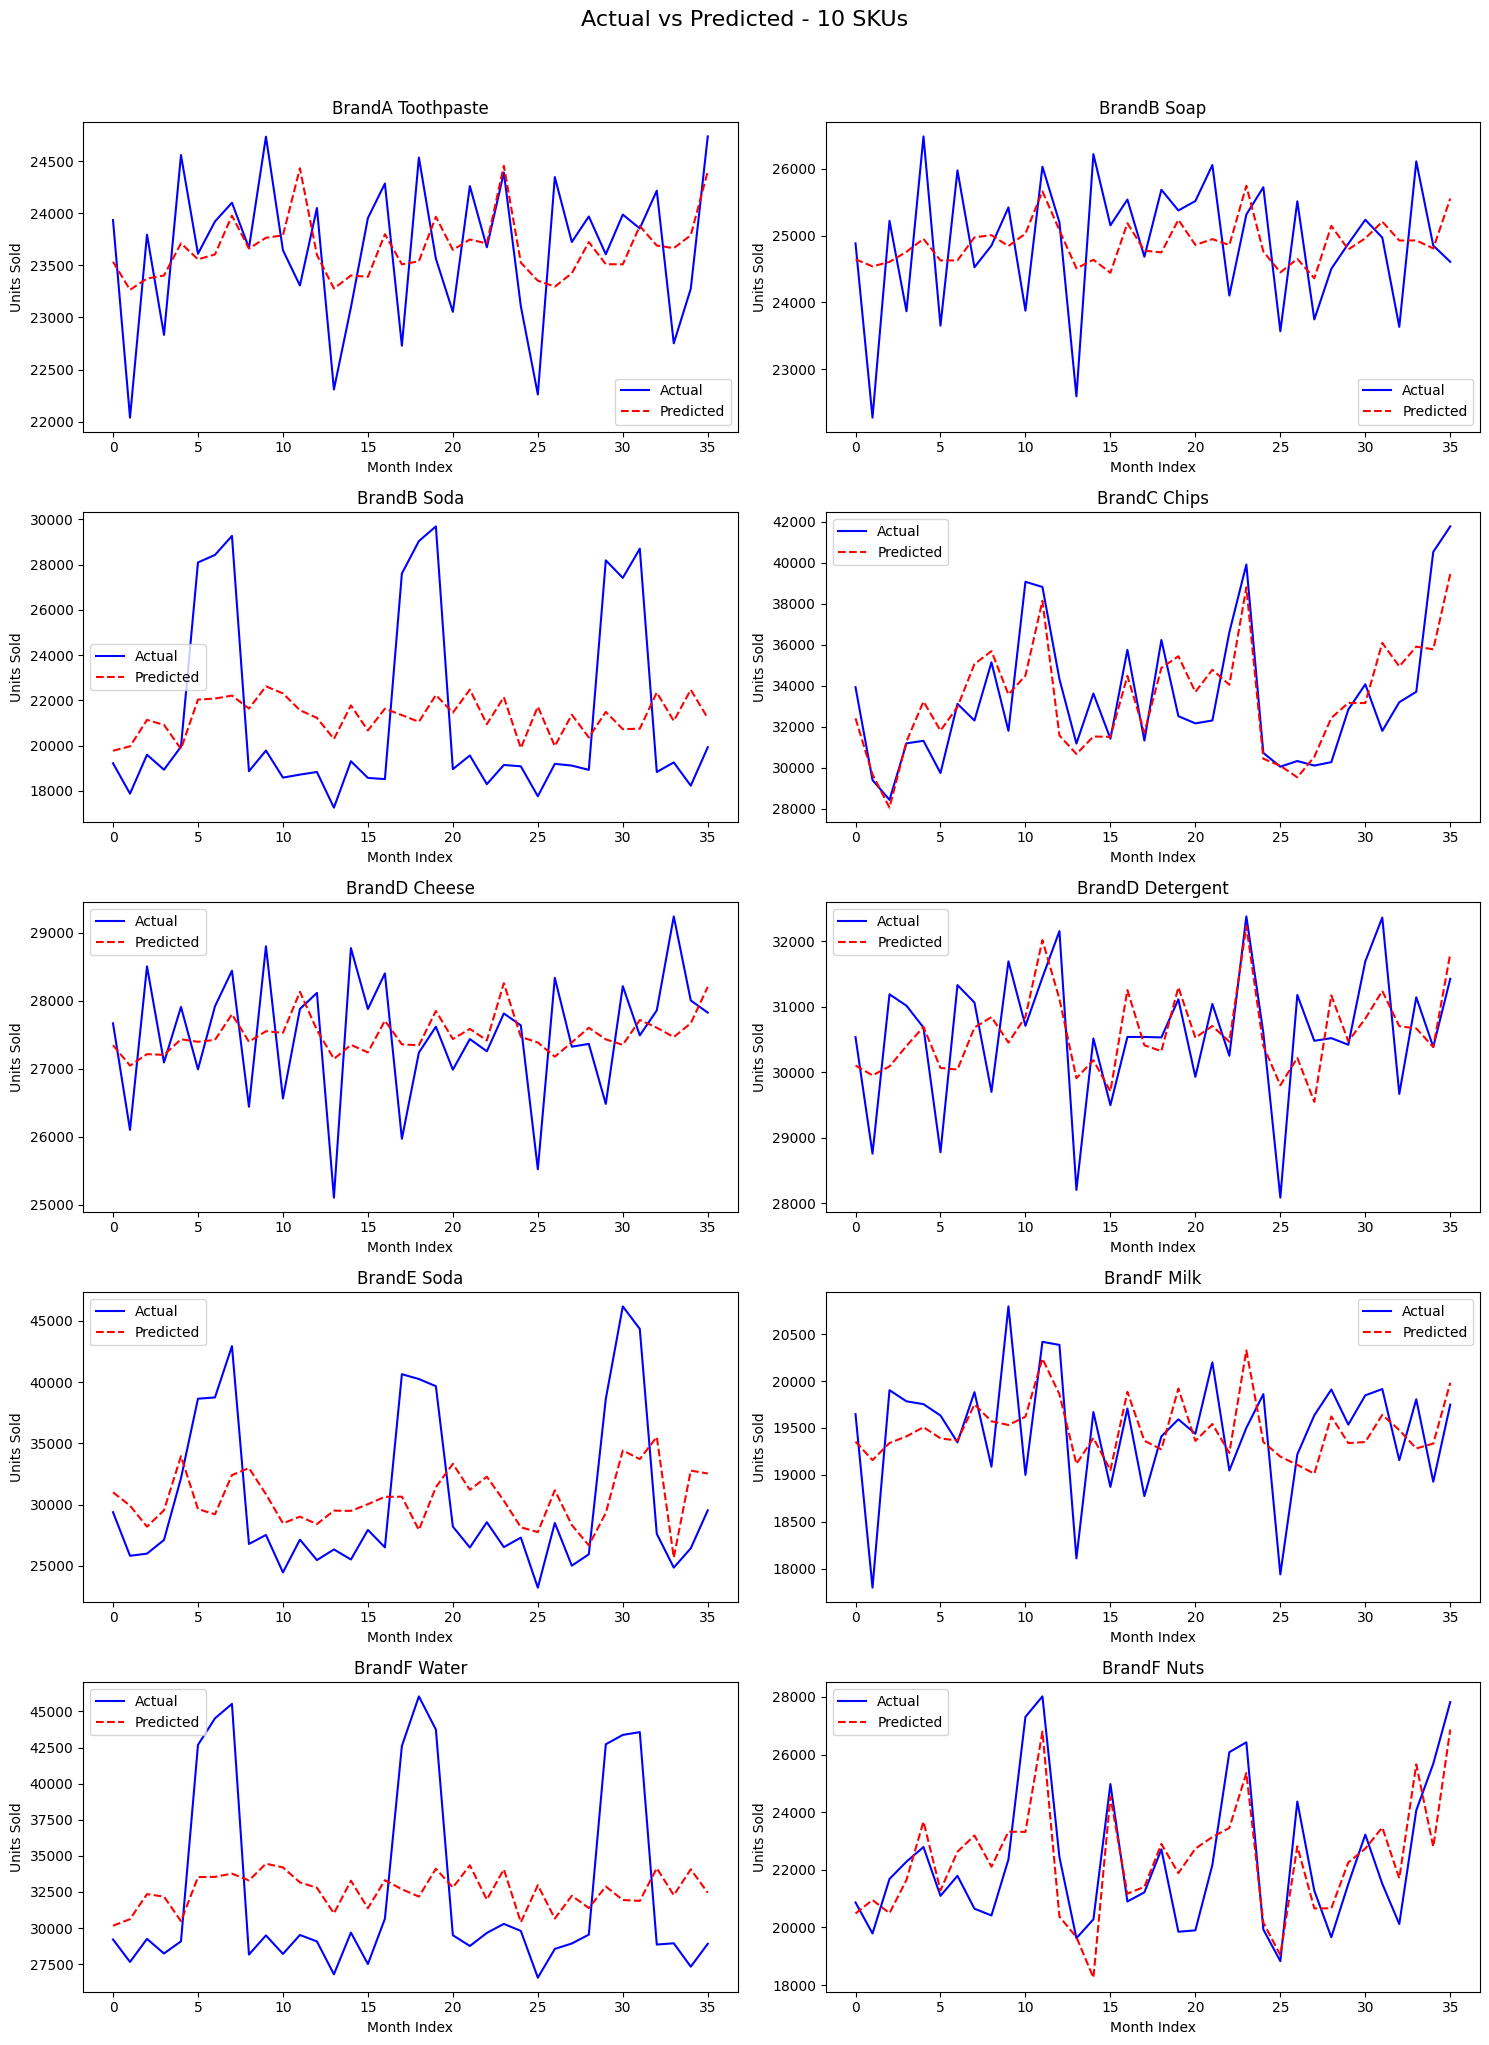

In [ ]:
# Visualizing The plot of the Actual vs Predicted Data
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, sku in enumerate(selected_skus):
  sku_data = sku_forecast_df3[sku_forecast_df3['sku_name'] == sku].copy()

  X = sku_data[['year', 'month', 'avg_discount',
                'avg_promo', 'avg_holiday',
                'avg_temp', 'avg_rain']]
  y = sku_data['units_sold']


  model = LinearRegression()
  model.fit(X, y)

  sku_data['predicted'] =model.predict(X)
  sku_data['time_index'] = range(len(sku_data))

  axes[i].plot(sku_data['time_index'], y,
               label='Actual', color='blue')
  axes[i].plot(sku_data['time_index'], sku_data['predicted'],
               label='Predicted', color='red', linestyle = '--')
  axes[i].set_title(f'{sku}')
  axes[i].legend()
  axes[i].set_xlabel('Month Index')
  axes[i].set_ylabel('Units Sold')

plt.suptitle('Actual vs Predicted - 10 SKUs',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Create future dates - next 6 months after 2023

import pandas as pd
import numpy as np

future_months = pd.DataFrame({
    'year': [2024] * 6,
    'month': [1, 2, 3, 4, 5, 6],
    'avg_discount': [df['discount_pct'].mean()] *6,
    'avg_promo': [df['promo_flag'].mean()]*6,
    'avg_holiday':[df['is_holiday'].mean()]*6,
    'avg_temp': [df['temperature'].mean()]*6,
    'avg_rain': [df['rain_mm'].mean()]*6
    })
print("Future forecast for first 6 months of 2024:")
print("="*50)

for sku in selected_skus:
  sku_data = sku_forecast_df3[sku_forecast_df3['sku_name'] == sku].copy()

  X = sku_data[['year', 'month', 'avg_discount',
                'avg_promo', 'avg_holiday',
                'avg_temp', 'avg_rain']]
  y = sku_data['units_sold']

  model = LinearRegression()
  model.fit(X, y)

  forecast = model.predict(future_months)
  print(f"\n{sku}:")
  for month, pred in zip(range(1, 7), forecast):
    print(f" Month {month}: {pred:,.0f} units")

Future forecast for first 6 months of 2024:

BrandA Toothpaste:
 Month 1: 23,331 units
 Month 2: 23,385 units
 Month 3: 23,440 units
 Month 4: 23,494 units
 Month 5: 23,549 units
 Month 6: 23,603 units

BrandB Soap:
 Month 1: 24,673 units
 Month 2: 24,715 units
 Month 3: 24,758 units
 Month 4: 24,800 units
 Month 5: 24,843 units
 Month 6: 24,885 units

BrandB Soda:
 Month 1: 19,831 units
 Month 2: 20,023 units
 Month 3: 20,214 units
 Month 4: 20,405 units
 Month 5: 20,597 units
 Month 6: 20,788 units

BrandC Chips:
 Month 1: 28,477 units
 Month 2: 29,068 units
 Month 3: 29,660 units
 Month 4: 30,252 units
 Month 5: 30,843 units
 Month 6: 31,435 units

BrandD Cheese:
 Month 1: 27,316 units
 Month 2: 27,361 units
 Month 3: 27,406 units
 Month 4: 27,452 units
 Month 5: 27,497 units
 Month 6: 27,542 units

BrandD Detergent:
 Month 1: 30,292 units
 Month 2: 30,363 units
 Month 3: 30,435 units
 Month 4: 30,506 units
 Month 5: 30,578 units
 Month 6: 30,649 units

BrandE Soda:
 Month 1: 24,487

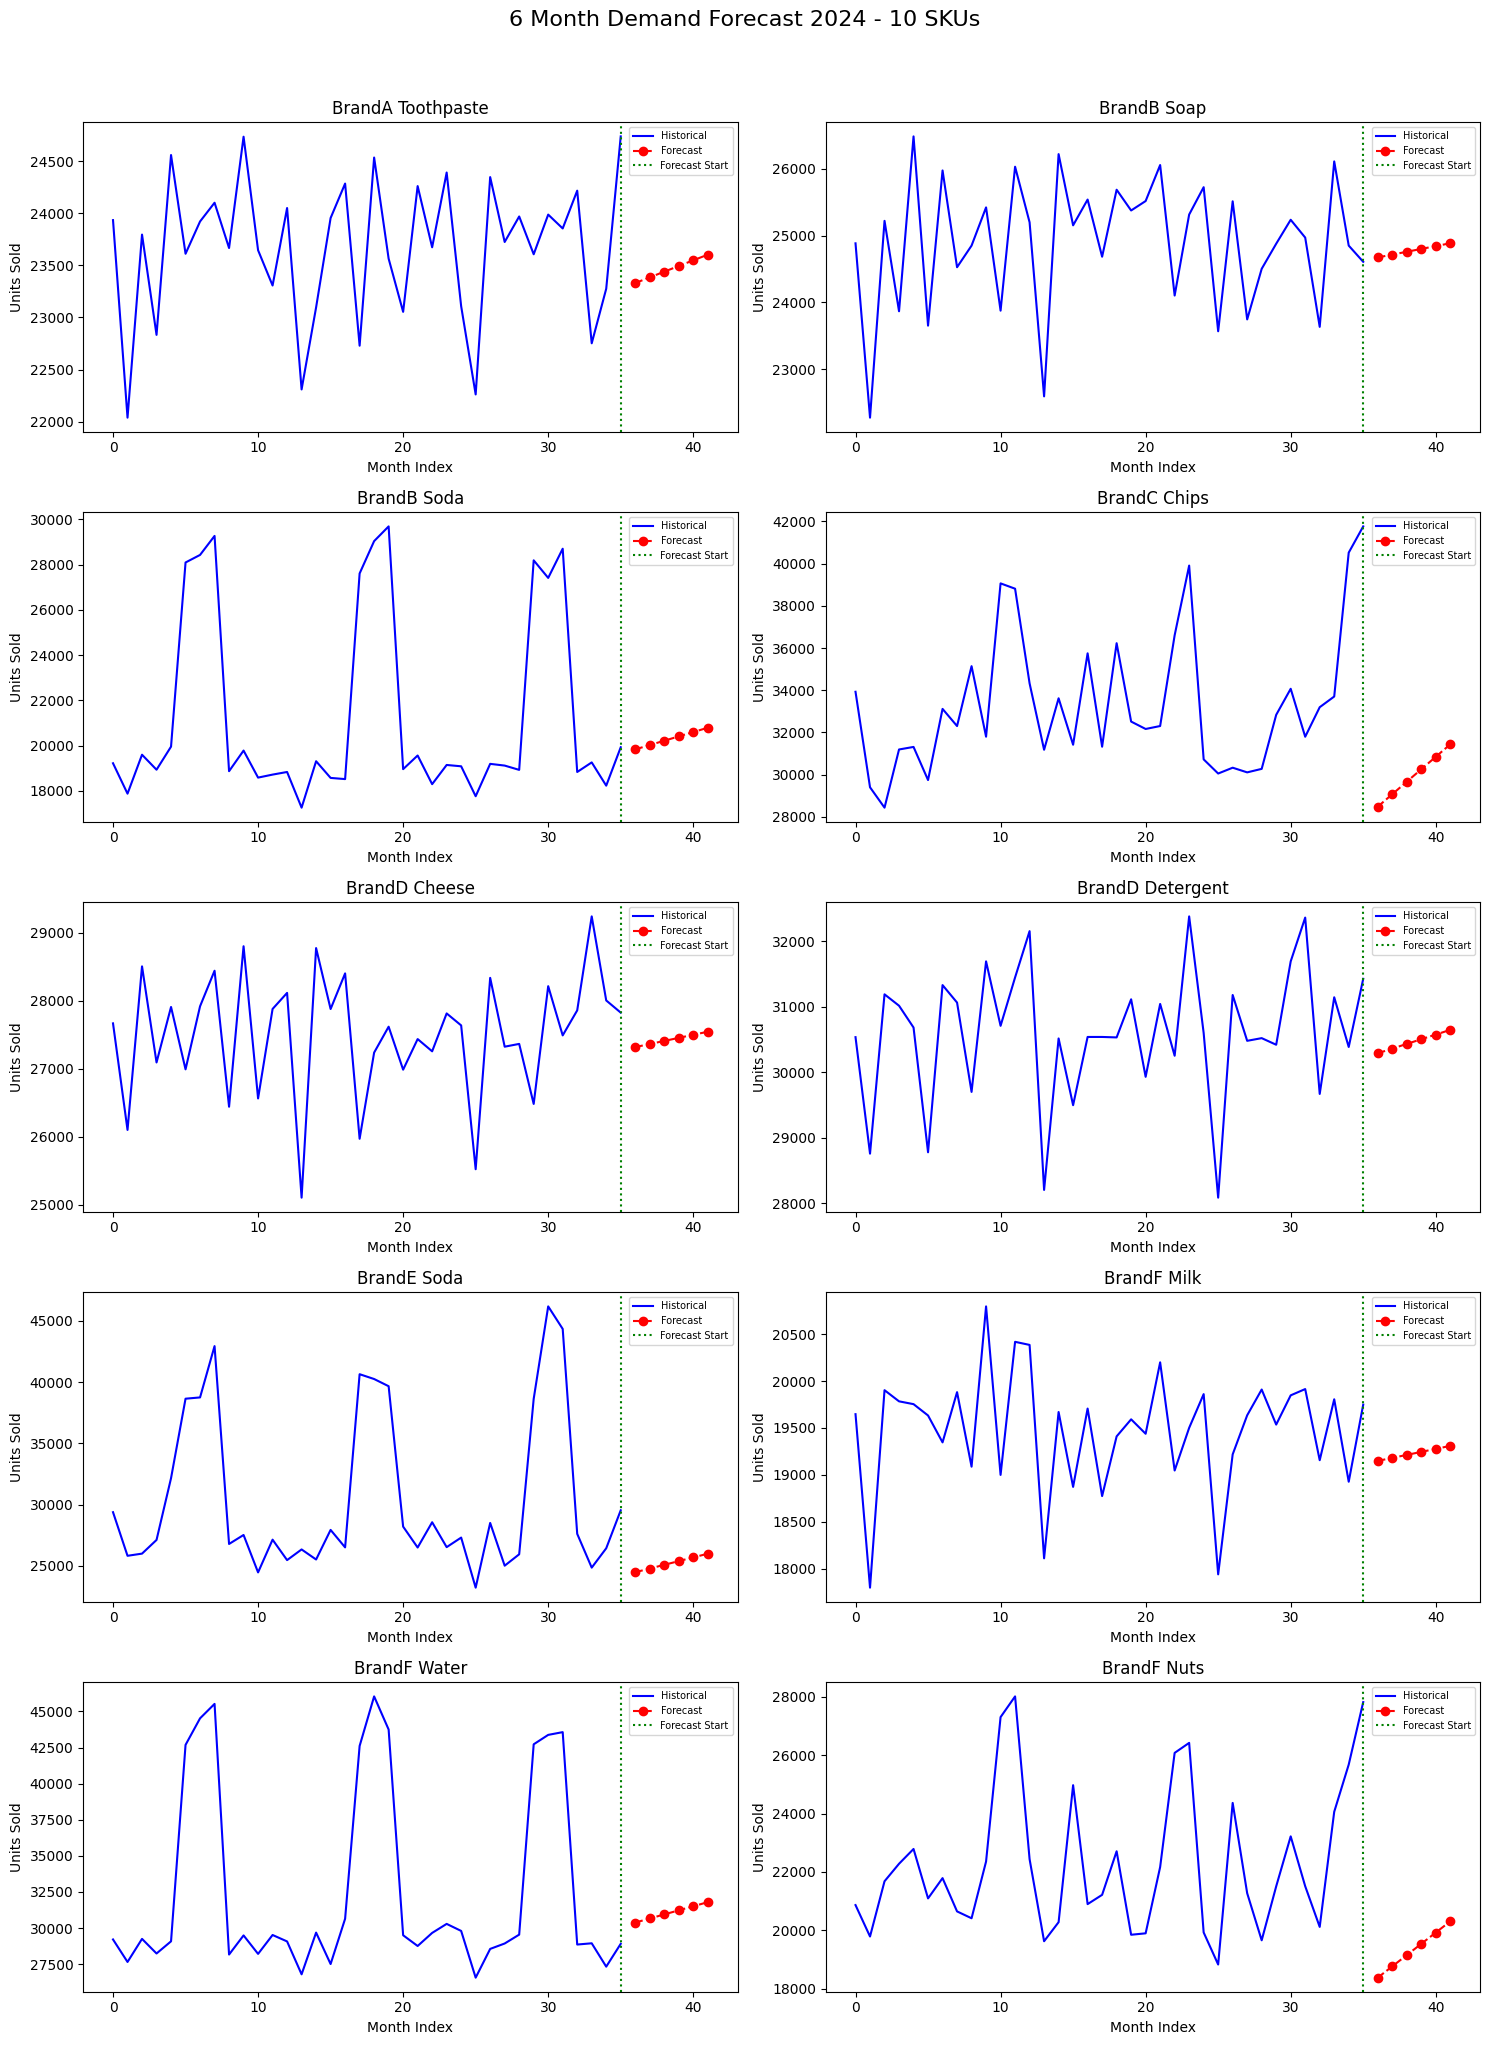

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, sku in enumerate(selected_skus):
  sku_data = sku_forecast_df3[sku_forecast_df3['sku_name'] == sku].copy()

  X = sku_data[['year', 'month', 'avg_discount',
                'avg_promo', 'avg_holiday',
                'avg_temp', 'avg_rain']]
  y = sku_data['units_sold']

  model = LinearRegression()
  model.fit(X, y)

  forecast = model.predict(future_months)

  # Plot historical
  axes[i].plot(range(36), y,
               label='Historical', color='blue')
  # Plot forecast
  axes[i].plot(range(36, 42), forecast,
               label = 'Forecast', color='red',
               linestyle='--', marker='o')

  axes[i].axvline(x=35, color='green',
                  linestyle=':', label='Forecast Start')
  axes[i].set_title(f'{sku}')
  axes[i].legend(fontsize=7)
  axes[i].set_xlabel('Month Index')
  axes[i].set_ylabel('Units Sold')

plt.suptitle('6 Month Demand Forecast 2024 - 10 SKUs',
            fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
